<a href="https://colab.research.google.com/github/AishaZAhmed/LLM-Fine-Tuning-For-Food-Hazard-Detection/blob/main/LLM_Fine_Tuning_for_Food_Hazard_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LLM Fine-Tuning for Food Hazard Detection By Aisha Ahmed**




## Summary of SemEval-2025 Task 9: The Food Hazard Detection Challenge:

This is a challenge to produce text-based food hazard prediction with long tail distributed classes. Algorithms as such could, for example, be used to help automated crawlers find and extract food issues from publicly available sources (e.g. social media). One major challenge posed in food-hazard and food-product classification from text is the large number of possible classes, combined with a long-tail distribution. The dataset used in the challenge is a subset from English food recall announcements from the official websites of food agencies. In addition, the dataset contains meta information such as date of download and country of issue. These texts were primarily gathered between 2012 and 2022 from domains based in the US, Australia, Canada, and the UK.



## 1. Dataset

○ dataset schema (columns)

1.	Year
2.	month	day
3.	title
4.	product
5.	product-category
6.	product-title
7.	hazard
8.	hazard-category
9.	hazard-title
10.	language
11.	country





**○ label spaces (how many unique hazard/product categories and values)**\
```
Number of unique hazard categories: 10
Hazard categories:
 ['biological' 'foreign bodies' 'chemical' 'fraud' 'organoleptic aspects'
 'allergens' 'packaging defect' 'other hazard'
 'food additives and flavourings' 'migration']

```
```
Number of unique product categories: 22
Product categories:
 ['meat, egg and dairy products' 'prepared dishes and snacks'
 'cereals and bakery products' 'confectionery' 'ices and desserts'
 'alcoholic beverages' 'fruits and vegetables'
 'other food product / mixed'
 'cocoa and cocoa preparations, coffee and tea'
 'nuts, nut products and seeds' 'seafood'
 'soups, broths, sauces and condiments' 'fats and oils'
 'non-alcoholic beverages' ':food contact materials'
 'dietetic foods, food supplements, fortified foods' 'herbs and spices'
 'food additives and flavourings' 'sugars and syrups'
 'honey and royal jelly' 'feed materials' 'pet feed']

```


**○ class imbalance observations (e.g., top-5 most frequent labels)**
```
Top 5 most frequent hazard categories:
hazard-category
biological        2020
allergens         1955
foreign bodies     769
chemical           498
fraud              411
```
```
Top 5 most frequent product categories:
product-category
meat, egg and dairy products    1687
cereals and bakery products      778
fruits and vegetables            655
prepared dishes and snacks       516
nuts, nut products and seeds     321
```
```
Rare product categories (<=10 examples):
product-category
honey and royal jelly    10
feed materials            6
sugars and syrups         5
```


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("food_recall_incidents v2.csv")

# =========================
# 1. Label Space
# =========================

# Unique hazard categories
hazard_categories = df["hazard-category"].dropna().unique() #df - dataframe
num_hazard_categories = len(hazard_categories)

# Unique product categories
product_categories = df["product-category"].dropna().unique()
num_product_categories = len(product_categories)

print("Number of unique hazard categories:", num_hazard_categories)
print("Hazard categories:\n", hazard_categories)

print("\nNumber of unique product categories:", num_product_categories)
print("Product categories:\n", product_categories)

# =========================
# 2️. Class Imbalance (Hazards)
# =========================

hazard_counts = df["hazard-category"].value_counts()

print("\nTop 5 most frequent hazard categories:")
print(hazard_counts.head(5))

print("\nRare hazard categories (<=10 examples):")
print(hazard_counts[hazard_counts <= 10])

# =========================
# 3️. Class Imbalance (Products)
# =========================

product_counts = df["product-category"].value_counts()

print("\nTop 5 most frequent product categories:")
print(product_counts.head(5))

print("\nRare product categories (<=10 examples):")
print(product_counts[product_counts <= 10])


Number of unique hazard categories: 10
Hazard categories:
 ['biological' 'foreign bodies' 'chemical' 'fraud' 'organoleptic aspects'
 'allergens' 'packaging defect' 'other hazard'
 'food additives and flavourings' 'migration']

Number of unique product categories: 22
Product categories:
 ['meat, egg and dairy products' 'prepared dishes and snacks'
 'cereals and bakery products' 'confectionery' 'ices and desserts'
 'alcoholic beverages' 'fruits and vegetables'
 'other food product / mixed'
 'cocoa and cocoa preparations, coffee and tea'
 'nuts, nut products and seeds' 'seafood'
 'soups, broths, sauces and condiments' 'fats and oils'
 'non-alcoholic beverages' 'food contact materials'
 'dietetic foods, food supplements, fortified foods' 'herbs and spices'
 'food additives and flavourings' 'sugars and syrups'
 'honey and royal jelly' 'feed materials' 'pet feed']

Top 5 most frequent hazard categories:
hazard-category
biological        2020
allergens         1955
foreign bodies     769
chem

## 2. LLM Fine-Tuning
○  Data preprocessing

  In the above code, Pandas open source library features such as .dropna() was used to remove missing values from a dataset by dropping the entire row.

In addition, the scikit-learn open source machine learning libray contains a function called LabelEncoder(), which was used to convert human-readable labels into integer class IDs. Scikit was also used for computing the evaluation metric (accuracy, macro F1, and micro F1).

Model training was conducted using the HuggingFace Transformers library (AI platform to easily discover and use models in Python) built on PyTorch (neural network computation).


○ Pretrained model

The pretrained model being used for this project is RoBERTa. RoBERTa is pretrained on: Wikipedia, Books, Web text, etc.


  What to expect when Fine-Tuning:

Before fine-tuning, the RoBERTa knows language, but not the specific classification of food hazard. Once a classification head is added and it is trained on chosen hazard labels, it will learn and adapt according to the task.


○ Fine-tune it on the training data

Please refer to the code below.


In [1]:
!pip install transformers[torch] datasets accelerate -U

In [2]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# =========================
# 1. Load Dataset
# =========================

df = pd.read_csv("food_recall_incidents v2.csv")

# Use hazard-category as label
df = df[["title", "hazard-category"]].dropna()

# Encode labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["hazard-category"])

num_labels = len(label_encoder.classes_)
print("Number of labels:", num_labels)

# Train/Validation split 80 training 20 validation
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

#Convert to HuggingFace Datase
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# =========================
# 2. Tokenization
# =========================
#tokenizer, translates text to numbers, token is a keyword
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["title"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# =========================
# 3. Load Model
# =========================

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# =========================
# 4. Metrics
# =========================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1)

    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    micro_f1 = f1_score(labels, predictions, average="micro")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1
    }

# =========================
# 5. Training Arguments
# =========================

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

# =========================
# 6. Trainer
# =========================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# =========================
# 7. Train
# =========================

trainer.train()

# =========================
# 8. Evaluate
# =========================

results = trainer.evaluate()
print(results)

# =========================
# 9. Save Model
# =========================

model.save_pretrained("./fine_tuned_model")
tokenizer.save_pretrained("./fine_tuned_model")

print("Training complete and model saved.")

Number of labels: 10


Map:   0%|          | 0/4787 [00:00<?, ? examples/s]

Map:   0%|          | 0/1197 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RuntimeError: on_train_begin must be called before on_evaluate

○ Report training details

**Steps to Train Model:**
1. Load dataset
2. Clean & encode labels
3. Split data
4. Tokenize text
5. Load pretrained model
6. Define metrics
7. Define training settings
8. Train
9. Evaluate
10. Save model

**Tools Used:**
1. HuggingFace - Model + training
2. Pytorch - Neural network computation
3. Scikit-learn - Data prep + evaluation metrics
4. Pandas - Data preprocessing


##3) Evaluation

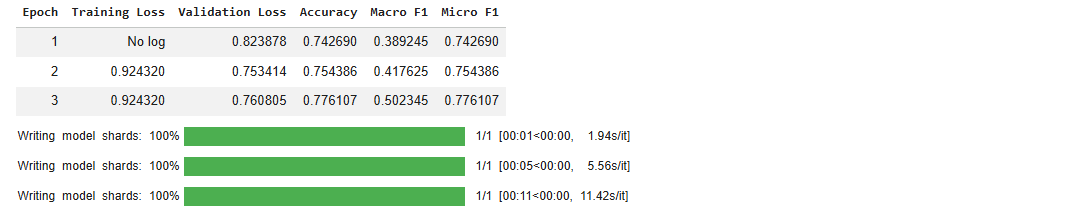

According to the table above, the Macro F1 score after 3 epoches (passes of the training dataset through our model) is **0.502345**. Similarly, the Mirco F1 score after 3 epoches is **0.776107**.


##Additional Learning

What is the F1 score?

The F1 score combines two metrics: Precision and recall into a single value.

Precision measures the accuracy of positive predictions. \
Recall measures the ability to find all actual positives.\
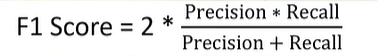


Tokenization Vs. Label Encoding

Label encoding assigns a unique integer value to each distinct category in a dataset, transforming textual labels into a single numerical column.

Best For: Ordinal data, where the categories have a natural, meaningful order (e.g., "Small"=0, "Medium"=1, "Large"=2).


Tokenization: Textual/NLP Data
Tokenization splits raw text into smaller pieces (tokens) that can be processed by language models.

E.g.
Word-based Tokenization: Splitting by spaces and punctuation ("The cat" -> ["The", "cat"]).